In [3]:

import sys
sys.path.append('..')


from mri_loader import Subject
from nilearn.glm.first_level import FirstLevelModel

import pandas as pd
import numpy as np

from stats import *




In [4]:
subject_ids = [2, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]

run_ids = list(range(1,5))

(subject_ids, run_ids)

([2, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24],
 [1, 2, 3, 4])

In [7]:
s0 = Subject(subject_ids[0], run_ids, folder="..")

In [8]:
low, high = s0.compute_inflexions()

In [9]:
low, high

(np.float64(0.2743243243243243), np.float64(0.7247747747747747))

In [10]:
all_labels = pd.concat([ds.labels for ds in s0._dataset], ignore_index=True)

cur_mean, cur_std = compute_morph_scores(all_labels)

_, fitted_curve = fit_sigmoid(cur_mean)


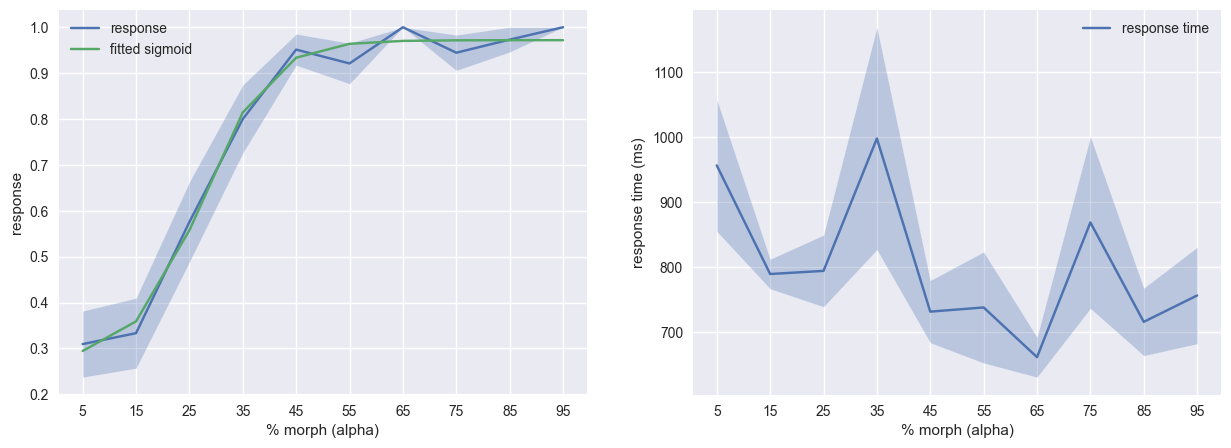

In [11]:
plot_behavioral_data(cur_mean, cur_std,
                     sigmoid_curve=fitted_curve)


In [13]:
low_quartile = np.percentile(fitted_curve, 25)
high_quartile = np.percentile(fitted_curve, 75)


In [15]:
low_quartile, high_quartile

(np.float64(0.62187772267844), np.float64(0.9711554812216568))

In [18]:

curve = np.array(cur_mean["response"])

low_inflexion = find_inflexion(curve, low_quartile)
high_inflexion = find_inflexion(curve, high_quartile)


In [19]:
low_inflexion, high_inflexion

(np.float64(0.2698198198198198), np.float64(0.613063063063063))

In [20]:



s22 = Subject(22, run_ids, folder="..")

s22.load()

In [21]:
s22.get_data()
s22.compute_inflexions()


EOFError: Compressed file ended before the end-of-stream marker was reached

In [22]:
len([2, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 21, 23])

16